# 16 — Clustering su sentence embeddings (SBERT + K-means)

Implementa il metodo della **§3.7** del [documento-guida](../Tecniche_MDS_non_LLM_MultiNews.md)
("Clustering su sentence embedding, BERT / SBERT"). L'idea è in tre mosse:

1. ogni frase del cluster di articoli diventa un **vettore denso** calcolato da un encoder
   pre-addestrato (**SBERT**, `all-MiniLM-L6-v2`) — vettori vicini = **significato** vicino,
   *anche senza parole in comune*;
2. si **raggruppa** l'insieme delle frasi in `k` gruppi omogenei (clustering);
3. da ogni gruppo si estrae **una** frase, quella più vicina al centroide del proprio gruppo (il
   *medoide*), cioè il rappresentante più tipico di quel sottotema.

Il riassunto è quindi l'insieme dei rappresentanti dei sottotemi. È la ricetta di
`bert-extractive-summarizer` (Miller, 2019), qui riscritta **da zero** con
`sentence-transformers` + scikit-learn per restare nella pipeline condivisa del benchmark
(segmentazione, ripresa, metriche identiche agli altri metodi).

**Perché la copertura tematica è garantita per costruzione.** I cluster sono una **partizione**:
scegliendo un rappresentante per ciascuno, il riassunto tocca necessariamente tutti i gruppi
individuati e non può contenere due frasi molto simili — sarebbero finite nello stesso cluster.
L'anti-ridondanza qui non è un termine da tarare (come il `λ` dell'MMR nel notebook 11): è una
**conseguenza strutturale** del partizionamento. Il confronto puntuale con il notebook 11 è nella
sezione dedicata più sotto.

## Due varianti di clustering (confronto)

Rappresentazione e regola di selezione restano identiche; cambia **solo** l'algoritmo di
raggruppamento, così il confronto isola l'effetto del clustering:

- **`sbert_kmeans`** — **K-means** (`sklearn.KMeans`, `k = N_SENTENCES`): partizione basata sulla
  distanza euclidea dai centroidi. Veloce, è l'impostazione classica del metodo.
- **`sbert_agglom`** — **clustering gerarchico agglomerativo**
  (`sklearn.AgglomerativeClustering`, `metric='cosine'`, `linkage='average'`): fonde
  iterativamente i gruppi più simili. Non assume cluster sferici e usa direttamente la **cosine
  similarity**, la metrica naturale degli embedding; è anche la famiglia citata a lezione
  (clustering gerarchico incrementale, Wang & Li 2010).

## Inquadramento nella lezione del Master

Copertura **piena**, come *neural summarization self-supervised* (slide 73-77): si imparano
rappresentazioni vettoriali del testo, si misura la similarità semantica con la cosine similarity
e si applicano ai vettori i metodi tradizionali. Pro citati a lezione: **alte prestazioni** e
**semantic-awareness**. Contro: **risorse hardware costose** e soprattutto **bassa spiegabilità** —
difficile motivare *perché* una specifica frase sia stata scelta (la sezione "passo per passo" di
questo notebook serve anche a mitigare in parte questo limite, rendendo visibili embedding,
cluster e medoidi).

> **Nota terminologica (importante per la relazione).** La tassonomia della lezione (slide 23 e 30)
> tiene esplicitamente distinte le categorie **"Pre-trained LM"** (BERT, BART, PEGASUS) e
> **"LLM"**. SBERT è un *encoder pre-addestrato*, non un modello generativo: usarlo **non viola**
> il vincolo "non-LLM" di questa parte del progetto. La variante *supervisionata*
> (BERTSum, MatchSum) è un'altra cosa e resta fuori.

Tre ambiti (`SCOPE`): `sample` (campione condiviso, default), `test` (intera split test pulita,
5.610 righe — impostato via `SUMM_SCOPE` da `scripts/run_benchmark_test.py`) e `full` (intero
`complete.tab` in streaming). L'encoding degli embedding è la parte pesante: su `test`/`full`
conviene la **GPU**, come per TextRank (notebook 01) e `centroid_mmr_bert` (notebook 11).
Riassunti salvati incrementalmente con **ripresa**; metriche ricalcolabili dai soli file salvati.

In [1]:
# Installa le dipendenze se mancanti (per esempio su Google Colab)
try:
    import pyAutoSummarizer  # noqa: F401  (segmentazione delle frasi + valutatore condiviso)
except ImportError:
    %pip install pyAutoSummarizer sentencepiece

try:
    import sentence_transformers  # noqa: F401  (embeddings SBERT)
except ImportError:
    %pip install sentence-transformers

try:
    import sklearn  # noqa: F401  (KMeans, AgglomerativeClustering, PCA)
except ImportError:
    %pip install scikit-learn

try:
    import matplotlib  # noqa: F401  (grafici della sezione di spiegazione)
except ImportError:
    %pip install matplotlib

C:\Users\maccu\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Configurazione ---------------------------------------------------------
import os

import summ_utils as su

# 'sample' (default) | 'test' (split test pulita) | 'full' (intero complete.tab);
# scripts/run_benchmark_test.py imposta SUMM_SCOPE='test'
SCOPE       = os.environ.get('SUMM_SCOPE', 'sample')
N_SAMPLES   = 100        # deve combaciare con il campione creato dal notebook 00
SEED        = 42
# es. 3 per uno smoke test rapido; None = tutti; SUMM_LIMIT usato da run_benchmark_test.py
LIMIT       = int(os.environ['SUMM_LIMIT']) if 'SUMM_LIMIT' in os.environ else None
N_SENTENCES = 11         # frasi selezionate per riassunto (mediana del corpus, come 01/02/11/15)
# Numero di cluster = numero di frasi da estrarre: una frase per cluster. Non e' un
# iperparametro libero, e' il budget del riassunto (cappato al numero di frasi disponibili).
N_CLUSTER   = N_SENTENCES
STOP_WORDS  = ['en']     # solo per la segmentazione con psr; l'output resta il testo originale
ST_MODEL    = 'all-MiniLM-L6-v2'  # stesso encoder del notebook 01 e di centroid_mmr_bert

# Le due varianti: stessi embedding, stessa selezione del medoide, clustering diverso
METODO_KMEANS = 'sbert_kmeans'
METODO_AGGLOM = 'sbert_agglom'
METODI        = [METODO_KMEANS, METODO_AGGLOM]

BASE   = su.trova_base_dir()
P      = su.percorsi_standard(BASE)
SAMPLE_PATH = P['sample_dir'] / f'sample_{N_SAMPLES}_seed{SEED}.tsv'
DEVICE = su.rileva_device()


def esempi_scope():
    """Iterabile degli esempi dell'ambito selezionato (riusato anche dalla valutazione)."""
    if SCOPE == 'sample':
        return su.carica_campione(SAMPLE_PATH)
    if SCOPE == 'test':
        return su.itera_split(P['complete_tab'], 'test')
    if SCOPE == 'full':
        return su.itera_complete_tab(P['complete_tab'])
    raise ValueError(f'SCOPE non valido: {SCOPE!r}')


print(f'Ambito (SCOPE)  : {SCOPE}')
print(f'Frasi/riassunto : {N_SENTENCES} (= numero di cluster)')
print(f'Encoder         : {ST_MODEL}')
print(f'Varianti        : {METODI}')
print(f'Device          : {DEVICE}')

Ambito (SCOPE)  : test
Frasi/riassunto : 11 (= numero di cluster)
Encoder         : all-MiniLM-L6-v2
Varianti        : ['sbert_kmeans', 'sbert_agglom']
Device          : cpu


## Generazione dei riassunti

Per ogni documento (separatore `` ||||| `` sostituito con newline dal ciclo condiviso) si istanzia
`psr.summarization` e se ne leggono le frasi originali (`s.original`, in ordine di documento) — la
**stessa** segmentazione di TextRank / LexRank / firstk_psr / centroid_mmr / lda / lsa, quindi il
pool di candidati è identico e i punteggi sono confrontabili. Poi:

1. **Encoding** delle frasi con SBERT (`all-MiniLM-L6-v2`, caricato **una sola volta**),
   embedding **L2-normalizzati** → il prodotto scalare *è* la cosine similarity.
2. **Clustering** in `k = min(N_CLUSTER, n_frasi)` gruppi — K-means oppure agglomerativo, unica
   differenza tra le due varianti.
3. **Medoide di ogni cluster**: la frase con cosine similarity massima rispetto al centroide del
   proprio cluster. Una frase per cluster → `k` frasi.
4. Frasi selezionate **riordinate in ordine di documento** e concatenate.

Le due varianti si generano in sequenza in file separati (`results/summaries/{metodo}_{scope}.tsv`),
ciascuna con **ripresa** automatica. Casi limite: se le frasi sono ≤ `N_SENTENCES` si restituiscono
tutte (nessun clustering da fare); se il clustering non è applicabile — il linkage cosine rifiuta
gli embedding nulli, che SBERT in pratica non produce mai — si ricade sulle prime `N_SENTENCES`
frasi, come negli altri notebook estrattivi.

In [3]:
import numpy as np
from pyAutoSummarizer.base import psr
from sklearn.cluster import AgglomerativeClustering, KMeans


def segmenta(documento):
    """Frasi del cluster con la segmentazione di psr.summarization (come TextRank/LexRank).

    `s.original` e' la lista delle frasi originali in ordine di documento. Si scartano
    le stringhe vuote.
    """
    s = psr.summarization(documento, stop_words=STOP_WORDS)
    return [f.strip() for f in getattr(s, 'original', []) if f and f.strip()]


_sbert = {}


def codifica(frasi):
    """Embedding SBERT delle frasi, (n, dim), L2-normalizzati. Modello caricato una volta.

    La normalizzazione rende il prodotto scalare uguale alla cosine similarity: tutte le
    "vicinanze" del notebook sono quindi la stessa cosa, misurata in un modo solo.
    """
    if 'model' not in _sbert:
        from sentence_transformers import SentenceTransformer
        _sbert['model'] = SentenceTransformer(ST_MODEL, device=DEVICE)
    return _sbert['model'].encode(frasi, normalize_embeddings=True, show_progress_bar=False)


# --- I due algoritmi di clustering (unica differenza tra le varianti) -------
def cluster_kmeans(E, k):
    """K-means sugli embedding -> etichette di cluster. Distanza euclidea."""
    return KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(E)


def cluster_agglomerativo(E, k):
    """Clustering gerarchico agglomerativo, cosine + average linkage -> etichette."""
    return AgglomerativeClustering(n_clusters=k, metric='cosine',
                                   linkage='average').fit_predict(E)


ALGORITMI = {METODO_KMEANS: cluster_kmeans, METODO_AGGLOM: cluster_agglomerativo}


def centroidi_e_medoidi(E, etichette):
    """Centroide di ogni cluster e frase piu' vicina a esso (medoide).

    Il centroide e' la media degli embedding del cluster, ri-normalizzata: e' un punto
    "medio" che non corrisponde ad alcuna frase reale. Il medoide e' la frase VERA piu'
    vicina a quel punto, cioe' il rappresentante piu' tipico del sottotema; e' quella che
    finisce nel riassunto (un riassunto estrattivo puo' solo copiare frasi esistenti).
    """
    centroidi, medoidi, vicinanze = {}, {}, {}
    for c in sorted(set(int(x) for x in etichette)):
        membri = np.where(etichette == c)[0]
        centro = E[membri].mean(axis=0)
        norma = np.linalg.norm(centro)
        centro = centro / norma if norma > 0 else centro
        sim = E[membri] @ centro               # cosine, gli embedding sono normalizzati
        centroidi[c] = centro
        medoidi[c] = int(membri[int(np.argmax(sim))])
        vicinanze[c] = sim
    return centroidi, medoidi, vicinanze


def analizza_clustering(frasi, algoritmo=None, k=None, E=None):
    """Pipeline completa su un pool di frasi, con tutti gli artefatti intermedi.

    Ritorna `E` (embedding), `etichette`, `centroidi`, `medoidi` ({cluster: indice frase}),
    `vicinanze` e `k`. `E` puo' essere passata dall'esterno per non ricodificare le stesse
    frasi quando si confrontano i due algoritmi (lo fa la sezione di spiegazione).
    """
    algoritmo = cluster_kmeans if algoritmo is None else algoritmo
    k = N_CLUSTER if k is None else k
    E = codifica(frasi) if E is None else E
    k = max(1, min(k, len(frasi)))
    etichette = algoritmo(E, k)
    centroidi, medoidi, vicinanze = centroidi_e_medoidi(E, etichette)
    return {'E': E, 'etichette': etichette, 'centroidi': centroidi, 'medoidi': medoidi,
            'vicinanze': vicinanze, 'k': k}


def make_genera(metodo):
    """Crea genera(documento) per una delle due varianti di clustering."""
    algoritmo = ALGORITMI[metodo]

    def genera(documento):
        frasi = segmenta(documento)
        if len(frasi) <= N_SENTENCES:
            return ' '.join(frasi)
        try:
            indici = sorted(analizza_clustering(frasi, algoritmo=algoritmo)['medoidi'].values())
        except ValueError:    # clustering non applicabile (es. embedding degeneri/nulli)
            indici = range(N_SENTENCES)
        return ' '.join(frasi[i] for i in indici)
    return genera


for metodo in METODI:
    out_path = P['summaries_dir'] / f'{metodo}_{SCOPE}.tsv'
    scrittore = su.ScrittoreRiassunti(out_path)
    print(f'== {metodo} -> {out_path.name} ==')
    su.ciclo_summarization(esempi_scope(), scrittore, make_genera(metodo),
                           limit=LIMIT, etichetta=f'{metodo} ')
    scrittore.chiudi()

C:\Users\maccu\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.6.0)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


== sbert_kmeans -> sbert_kmeans_test.tsv ==


  ERRORE su row_id=50531: IndexError('list assignment index out of range')
sbert_kmeans [1] media 8.5 s/esempio (saltati 40 gia' fatti)
  ERRORE su row_id=51364: IndexError('list assignment index out of range')
sbert_kmeans [2] media 4.3 s/esempio (saltati 872 gia' fatti)
  ERRORE su row_id=51439: IndexError('list assignment index out of range')
sbert_kmeans [3] media 2.9 s/esempio (saltati 946 gia' fatti)


  ERRORE su row_id=51478: IndexError('list assignment index out of range')
  ERRORE su row_id=51661: IndexError('list assignment index out of range')
  ERRORE su row_id=51788: IndexError('list assignment index out of range')
  ERRORE su row_id=52064: IndexError('list assignment index out of range')


  ERRORE su row_id=52413: IndexError('list assignment index out of range')
  ERRORE su row_id=52700: IndexError('list assignment index out of range')
  ERRORE su row_id=52751: IndexError('list assignment index out of range')
sbert_kmeans [10] media 0.9 s/esempio (saltati 2251 gia' fatti)
  ERRORE su row_id=52926: IndexError('list assignment index out of range')
  ERRORE su row_id=52960: IndexError('list assignment index out of range')


...

sbert_agglom [5010] media 1.2 s/esempio (saltati 569 gia' fatti)


sbert_agglom [5020] media 1.2 s/esempio (saltati 569 gia' fatti)


sbert_agglom [5030] media 1.2 s/esempio (saltati 569 gia' fatti)


sbert_agglom [5040] media 1.2 s/esempio (saltati 569 gia' fatti)


sbert_agglom Completato: 5041 nuovi, 569 saltati, 22 errori, 5861 s totali


## Come funziona, passo per passo

Questa sezione **apre la scatola nera** su un singolo documento-esempio (parametro `RIGA_DEMO`) e
mostra, con output e grafici intermedi, come si arriva dalle frasi grezze ai medoidi. È puramente
illustrativa: non tocca i riassunti/metriche prodotti sopra (`analizza_clustering` è la **stessa**
funzione usata in produzione). Serve anche a rispondere al contro segnalato a lezione — la **bassa
spiegabilità** — rendendo ispezionabile ogni passaggio.

### Che cos'è un sentence embedding

SBERT trasforma una frase in un vettore di 384 numeri. Non sono parole né conteggi: sono
coordinate in uno spazio dove **la posizione codifica il significato**, appreso in
pre-addestramento su grandi quantità di testo. Due frasi che raccontano lo stesso fatto con parole
diverse — *"the mayor resigned yesterday"* e *"city hall's leader stepped down"* — finiscono
**vicine**, mentre per il TF-IDF (notebook 11, variante lessicale) sarebbero quasi ortogonali:
nessuna parola in comune, similarità ≈ 0.

Questo è **il** motivo per cui il metodo è interessante su Multi-News: fonti diverse riportano gli
stessi fatti riformulandoli, e solo una misura semantica riconosce quelle riformulazioni come
ridondanti. Il **Passo 2** lo misura direttamente sul documento-esempio.

### I quattro passi

1. **Segmentazione** — pool di frasi candidate (identico agli altri estrattivi).
2. **Encoding** — ogni frase → vettore SBERT normalizzato; confronto tra similarità *semantica* e
   *lessicale*.
3. **Clustering** — le frasi vengono partizionate in `k` sottotemi; si visualizza lo spazio in 2D.
4. **Medoidi** — un rappresentante per cluster; confronto tra K-means e agglomerativo.

*Nota sui colori:* l'identità dei cluster è data da **posizione ed etichette `K0…Kk`**; il colore
la ribadisce ma non è mai l'unico canale.

In [4]:
# --- Setup della dimostrazione (Passo 1: segmentazione) ---------------------
import matplotlib.pyplot as plt

RIGA_DEMO    = 0        # indice del documento nel campione da ispezionare
SALVA_FIGURE = True     # salva anche i PNG in results/figures/sbert_clustering/
FIG_DIR      = P['metrics_dir'].parent / 'figures' / 'sbert_clustering'

# Palette coerente con i notebook 05/11/13/15
INK, MUTED, GRID, SURFACE, ACCENTO = '#0b0b0b', '#898781', '#e1e0d9', '#fcfcfb', '#0d9488'
CLUSTER_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4',
                  '#008300', '#4a3aa7', '#e34948', '#0d9488', '#a3561f', '#7a7ad6']
plt.rcParams.update({'font.family': 'sans-serif', 'text.color': INK,
                     'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def col_cluster(c):
    return CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)]


def _salva(fig, nome):
    if SALVA_FIGURE:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / nome, dpi=150, bbox_inches='tight', facecolor=SURFACE)
        print(f'  figura salvata: {FIG_DIR / nome}')


# Documento-esempio -> frasi. Se e' troppo corto per una demo significativa (<= N_SENTENCES
# frasi, nessun clustering), si avanza al primo documento piu' lungo del campione.
_campione = su.carica_campione(SAMPLE_PATH)
esempio = _campione[RIGA_DEMO]
frasi = segmenta(su.prepara_documento(esempio['document']))
if len(frasi) <= N_SENTENCES:
    for e in _campione[RIGA_DEMO:] + _campione[:RIGA_DEMO]:
        f = segmenta(su.prepara_documento(e['document']))
        if len(f) > N_SENTENCES:
            esempio, frasi = e, f
            break
rid = esempio['row_id']
articoli = [a for a in esempio['document'].split(su.SEPARATORE_ARTICOLI) if a.strip()]
print('PASSO 1 - Segmentazione')
print(f"Documento row_id={rid} (split={esempio['split']}): {len(articoli)} articoli -> "
      f'{len(frasi)} frasi nel pool')
print('Prime 3 frasi del pool:')
for i in range(min(3, len(frasi))):
    print(f'  [{i}] {frasi[i][:120]}')

PASSO 1 - Segmentazione
Documento row_id=425 (split=train): 3 articoli -> 71 frasi nel pool
Prime 3 frasi del pool:
  [0] Campaign mailer sent by GOP state Senate candidate Ed Charamut
  [1] The Jewish campaign treasurer for a Republican candidate in Connecticut is defending a campaign mailer that depicts thei
  [2] There’s also a lead tagline on the other side: “Matt Lesser will take everything you worked for.” It was mailed out to h


### Passo 2 — Encoding: la similarità semantica non è quella lessicale

Si codificano le frasi con SBERT e si confrontano **due** matrici di similarità sullo stesso pool:

- **semantica** — cosine tra gli embedding SBERT;
- **lessicale** — cosine tra i vettori TF-IDF (la rappresentazione della variante `centroid_mmr`
  del notebook 11).

Le due heatmap affiancate mostrano la differenza di struttura: quella semantica è molto più
"piena", perché riconosce affinità che il TF-IDF non vede. Lo **scatter** che segue mette a
confronto le due misure coppia per coppia: i punti in alto a sinistra — **alta similarità
semantica, bassa sovrapposizione lessicale** — sono esattamente le **parafrasi tra fonti diverse**,
il caso che il TF-IDF manca. Sotto vengono stampate le coppie più estreme, così si può leggere con
i propri occhi se il modello ha ragione.

PASSO 2 - Encoding
Embedding: 71 frasi x 384 dimensioni (norma media 1.000)


  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\sbert_clustering\similarita_row425.png


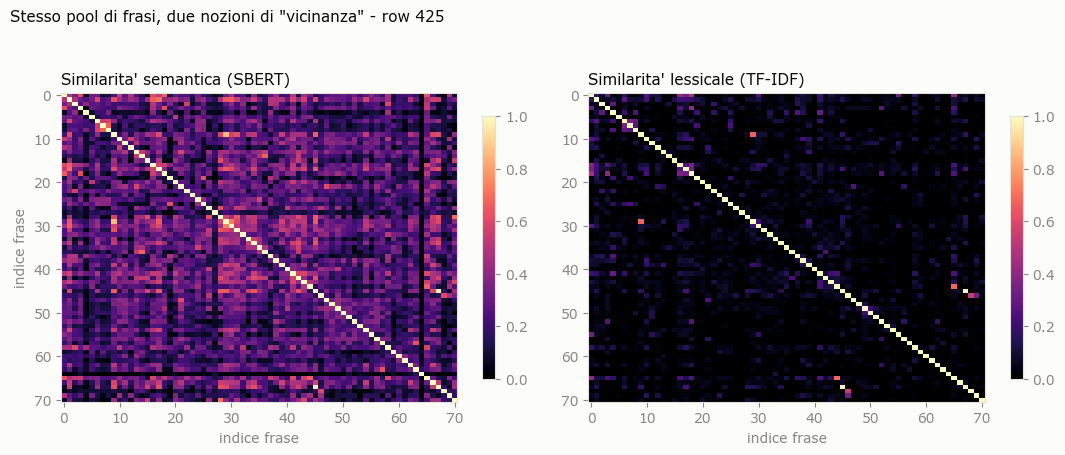

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\sbert_clustering\semantica_vs_lessicale_row425.png


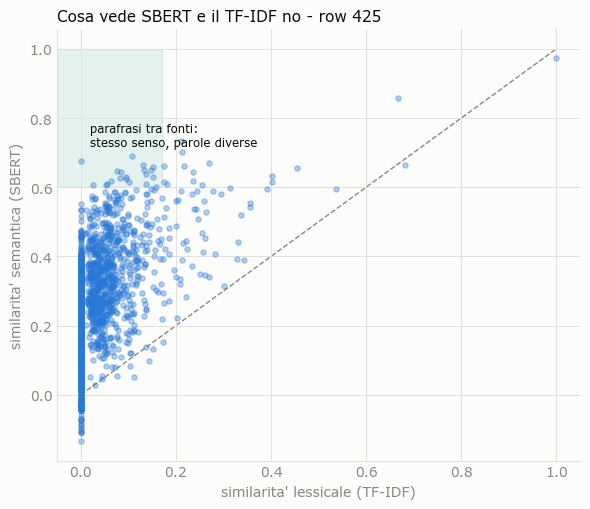


Coppie con il maggiore divario semantica - lessico (le parafrasi che il TF-IDF perde):
  frasi 14 e 36: SBERT=0.68 vs TF-IDF=0.00
    [14] “Those hateful words lead to violent acts
    [36] “I reject hate speech in all its forms
  frasi 28 e 70: SBERT=0.69 vs TF-IDF=0.11
    [28] “It is a concerted effort to fan the flames of anti-semitism and stir up fear and hatred.” 
 
 Jewish groups also found the ad offensive
    [70] I have requested to sit down with the ADL to broaden my understanding of and sensitivity to anti-Semitism.”
  frasi 28 e 42: SBERT=0.61 vs TF-IDF=0.03
    [28] “It is a concerted effort to fan the flames of anti-semitism and stir up fear and hatred.” 
 
 Jewish groups also found the ad offensive
    [42] “However, it is clear now that the imagery could be interpreted as anti-Semitic, and for that we deeply apologize as hate speech of any kind does not 
Similarita' media su tutte le coppie: SBERT 0.245, TF-IDF 0.027


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

E = codifica(frasi)                      # (n_frasi, 384), L2-normalizzati
S_sem = E @ E.T                          # cosine semantica
S_lex = cosine_similarity(TfidfVectorizer(stop_words='english').fit_transform(frasi))

print('PASSO 2 - Encoding')
print(f'Embedding: {E.shape[0]} frasi x {E.shape[1]} dimensioni (norma media '
      f'{np.linalg.norm(E, axis=1).mean():.3f})')

# --- Figura: le due matrici di similarita' affiancate -----------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), facecolor=SURFACE)
for ax, M, titolo in zip(axes, [S_sem, S_lex],
                         ['semantica (SBERT)', 'lessicale (TF-IDF)']):
    im = ax.imshow(M, cmap='magma', vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'Similarita\' {titolo}', color=INK, loc='left', fontsize=11)
    ax.set_xlabel('indice frase')
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].set_ylabel('indice frase')
fig.suptitle(f'Stesso pool di frasi, due nozioni di "vicinanza" - row {rid}', color=INK, x=0.01,
             ha='left', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
_salva(fig, f'similarita_row{rid}.png')
plt.show()

# --- Figura: semantica vs lessicale, coppia per coppia ----------------------
iu = np.triu_indices(len(frasi), k=1)            # solo la meta' superiore, senza diagonale
x_lex, y_sem = S_lex[iu], S_sem[iu]
fig, ax = plt.subplots(figsize=(6.0, 5.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.scatter(x_lex, y_sem, s=14, color=CLUSTER_COLORS[0], alpha=0.35, zorder=2)
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle='--', zorder=1)
ax.axhspan(0.6, 1.0, xmin=0, xmax=0.2, color=ACCENTO, alpha=0.10, zorder=0)
ax.set_xlabel('similarita\' lessicale (TF-IDF)')
ax.set_ylabel('similarita\' semantica (SBERT)')
ax.set_title(f'Cosa vede SBERT e il TF-IDF no - row {rid}', color=INK, loc='left', fontsize=11)
ax.annotate('parafrasi tra fonti:\nstesso senso, parole diverse', xy=(0.02, 0.72),
            fontsize=8.5, color=INK)
ax.grid(color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
_salva(fig, f'semantica_vs_lessicale_row{rid}.png')
plt.show()

# --- Le coppie piu' "semantiche ma non lessicali" ---------------------------
divario = y_sem - x_lex
print()
print('Coppie con il maggiore divario semantica - lessico (le parafrasi che il TF-IDF perde):')
for p in np.argsort(-divario)[:3]:
    i, j = int(iu[0][p]), int(iu[1][p])
    print(f'  frasi {i} e {j}: SBERT={S_sem[i, j]:.2f} vs TF-IDF={S_lex[i, j]:.2f}')
    print(f'    [{i}] {frasi[i][:150]}')
    print(f'    [{j}] {frasi[j][:150]}')
print(f'Similarita\' media su tutte le coppie: SBERT {y_sem.mean():.3f}, '
      f'TF-IDF {x_lex.mean():.3f}')

### Passo 3 — Clustering: la mappa dei sottotemi

Si partiziona il pool in `k = N_SENTENCES` gruppi. La figura proietta lo spazio a 384 dimensioni
su **due** con la PCA — è una compressione, quindi due punti vicini nel grafico potrebbero non
esserlo davvero nello spazio pieno: si legga come una mappa indicativa, non come la verità. Nel
grafico:

- **colore + etichetta `K0…Kk`** = cluster di appartenenza;
- **stella** = centroide del cluster (un punto medio, non una frase reale);
- **cerchio con bordo nero** = il **medoide**, la frase che entra nel riassunto.

La seconda figura mostra la **taglia dei cluster**. È il punto debole del metodo, ed è utile
vederlo: K-means con `k` fissato dal budget del riassunto produce spesso qualche cluster
*singoletto* — una frase isolata, magari un frammento di boilerplate — che riceve comunque uno dei
posti disponibili, esattamente come il cluster che raccoglie il fatto principale raccontato da
dieci fonti.

PASSO 3 - K-means con k=11 cluster su 71 frasi
Taglie dei cluster: {0: 3, 1: 11, 2: 10, 3: 2, 4: 11, 5: 7, 6: 8, 7: 2, 8: 7, 9: 4, 10: 6}
Singoletti (cluster con una sola frase): 0


  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\sbert_clustering\pca_cluster_row425.png


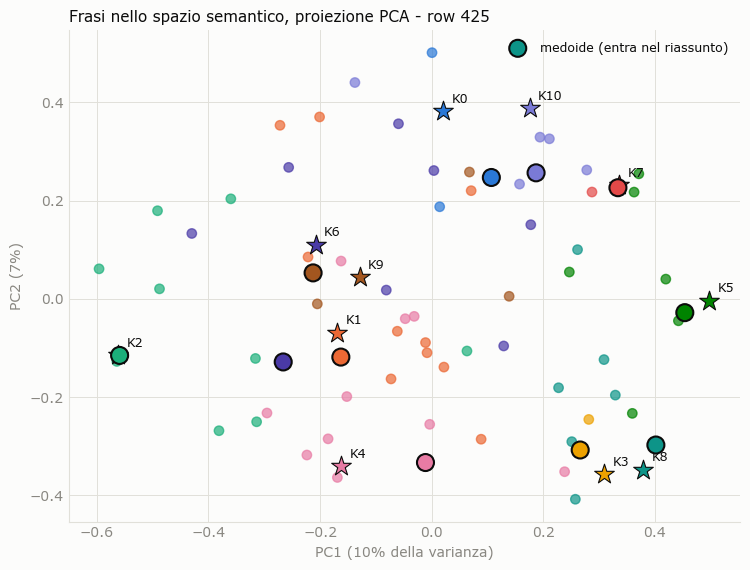

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\sbert_clustering\taglie_cluster_row425.png


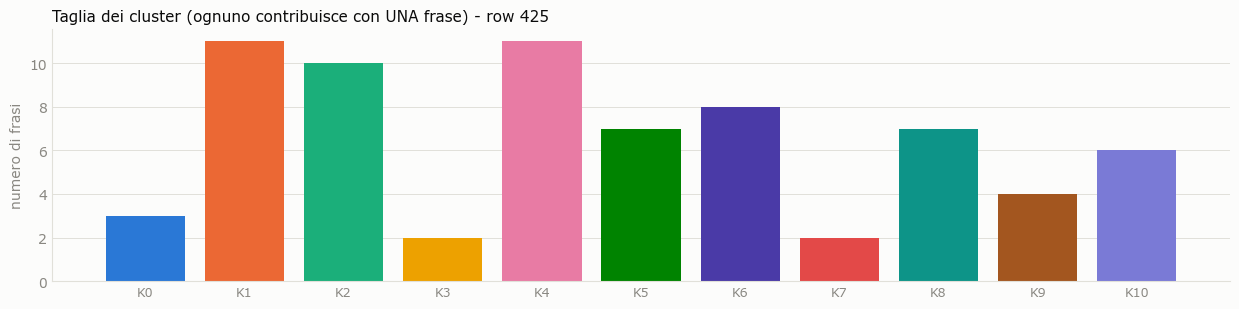

In [6]:
from sklearn.decomposition import PCA

art = analizza_clustering(frasi, algoritmo=cluster_kmeans, E=E)
etichette, centroidi, medoidi, k = (art['etichette'], art['centroidi'],
                                    art['medoidi'], art['k'])
scelti_kmeans = sorted(medoidi.values())
print(f'PASSO 3 - K-means con k={k} cluster su {len(frasi)} frasi')
taglie = {c: int((etichette == c).sum()) for c in sorted(medoidi)}
print(f'Taglie dei cluster: {taglie}')
print(f'Singoletti (cluster con una sola frase): {sum(1 for v in taglie.values() if v == 1)}')

# --- Figura: mappa PCA dei cluster ------------------------------------------
pca = PCA(n_components=2, random_state=SEED)
XY = pca.fit_transform(E)
CXY = pca.transform(np.vstack([centroidi[c] for c in sorted(centroidi)]))
sel = np.zeros(len(frasi), dtype=bool)
sel[scelti_kmeans] = True

fig, ax = plt.subplots(figsize=(7.6, 5.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.scatter(XY[~sel, 0], XY[~sel, 1], s=46, c=[col_cluster(c) for c in etichette[~sel]],
           alpha=0.7, zorder=2)
ax.scatter(XY[sel, 0], XY[sel, 1], s=150, c=[col_cluster(c) for c in etichette[sel]],
           edgecolors=INK, linewidths=1.5, zorder=4, label='medoide (entra nel riassunto)')
for n, c in enumerate(sorted(centroidi)):
    ax.scatter(CXY[n, 0], CXY[n, 1], s=220, marker='*', color=col_cluster(c),
               edgecolors=INK, linewidths=0.8, zorder=3)
    ax.annotate(f'K{c}', (CXY[n, 0], CXY[n, 1]), xytext=(6, 6), textcoords='offset points',
                fontsize=9, color=INK)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} della varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title(f'Frasi nello spazio semantico, proiezione PCA - row {rid}', color=INK, loc='left',
             fontsize=11)
ax.grid(color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=9, loc='best')
plt.tight_layout()
_salva(fig, f'pca_cluster_row{rid}.png')
plt.show()

# --- Figura: taglia dei cluster ---------------------------------------------
fig, ax = plt.subplots(figsize=(1.0 * k + 1.5, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ordine = sorted(taglie)
ax.bar(range(len(ordine)), [taglie[c] for c in ordine],
       color=[col_cluster(c) for c in ordine], zorder=2)
ax.set_xticks(range(len(ordine)))
ax.set_xticklabels([f'K{c}' for c in ordine], fontsize=9)
ax.set_ylabel('numero di frasi')
ax.set_title(f'Taglia dei cluster (ognuno contribuisce con UNA frase) - row {rid}', color=INK,
             loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
_salva(fig, f'taglie_cluster_row{rid}.png')
plt.show()

### Passo 4 — I medoidi, e le due varianti a confronto

Dentro ogni cluster si prende la frase più vicina al centroide. La prima stampa mostra, cluster per
cluster, quanto il medoide è "tipico" (cosine col centroide) e quanto è affollato il gruppo che
rappresenta: un medoide con cosine alta in un cluster numeroso è una scelta solida; un singoletto
con cosine 1.0 è solo una frase che non somiglia a nulla.

Poi si ripete tutto con il **clustering agglomerativo** sugli **stessi** embedding e si confrontano
i due esiti: quante frasi in comune, e quanto è **ridondante** ciascun riassunto (similarità coseno
media tra le frasi scelte — la misura che in Multi-News conta davvero, perché le fonti si ripetono
tra loro).

PASSO 4 - Medoidi (K-means)
  K0 ( 3 frasi, cosine col centroide 0.756)  [23] “I did not believe them, because we live in America,” he said
  K1 (11 frasi, cosine col centroide 0.770)  [21] The embrace of racially charged policies and rhetoric by Republicans, from President Trump to candidates acros
  K2 (10 frasi, cosine col centroide 0.895)  [45] “In a race with a Jewish candidate, this image should be recognized as offensive, raising classic anti-Semitic
  K3 ( 2 frasi, cosine col centroide 0.837)  [55] [GOP candidate for Fla
  K4 (11 frasi, cosine col centroide 0.844)  [ 1] The Jewish campaign treasurer for a Republican candidate in Connecticut is defending a campaign mailer that de
  K5 ( 7 frasi, cosine col centroide 0.815)  [ 2] There’s also a lead tagline on the other side: “Matt Lesser will take everything you worked for.” It was maile
  K6 ( 8 frasi, cosine col centroide 0.764)  [31] https://t.co/SlG90OA2S4 pic.twitter.com/vBE5ewKXeM — Amanda Terkel (@aterkel) October 30, 201

  figura salvata: C:\Users\maccu\OneDrive\Desktop\Master_Project\results\figures\sbert_clustering\ridondanza_row425.png


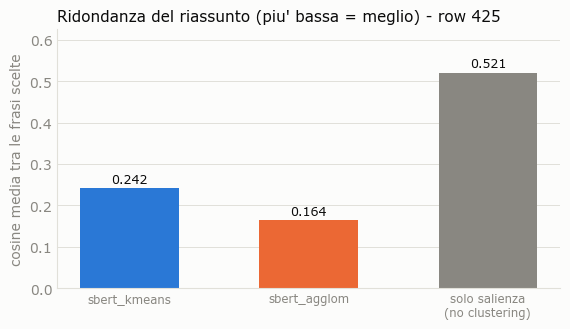


Ridondanza media (cosine semantica) del set scelto:
  sbert_kmeans    : 0.242
  sbert_agglom    : 0.164
  solo salienza   : 0.521

Frasi selezionate (ordine di documento). [K]=solo kmeans, [A]=solo agglomerativo, [=]=entrambe
  [K] [ 0] Campaign mailer sent by GOP state Senate candidate Ed Charamut
  [K] [ 1] The Jewish campaign treasurer for a Republican candidate in Connecticut is defending a campaign mailer that depicts their Democrat
  [=] [ 2] There’s also a lead tagline on the other side: “Matt Lesser will take everything you worked for.” It was mailed out to homes in an
  [A] [ 7] “His eyes were altered to look bigger and greedy,” Greenspan admitted
  [K] [19] Matthew Lesser, holding a wad of cash in front of him, with a crazed look in his eyes
  [K] [21] The embrace of racially charged policies and rhetoric by Republicans, from President Trump to candidates across the country, has e
  [=] [23] “I did not believe them, because we live in America,” he said
  [K] [24] “I assumed 

In [7]:
print('PASSO 4 - Medoidi (K-means)')
for c in sorted(medoidi):
    i = medoidi[c]
    print(f'  K{c} ({taglie[c]:>2} frasi, cosine col centroide '
          f'{float(art["vicinanze"][c].max()):.3f})  [{i:>2}] {frasi[i][:110]}')

# --- Stessa pipeline, clustering agglomerativo ------------------------------
art_agg = analizza_clustering(frasi, algoritmo=cluster_agglomerativo, E=E)
scelti_agglom = sorted(art_agg['medoidi'].values())
taglie_agg = {c: int((art_agg['etichette'] == c).sum()) for c in sorted(art_agg['medoidi'])}
comuni = sorted(set(scelti_kmeans) & set(scelti_agglom))
print()
print(f'  {METODO_KMEANS:<14}: {scelti_kmeans}')
print(f'  {METODO_AGGLOM:<14}: {scelti_agglom}')
print(f'  frasi in comune: {len(comuni)}/{len(scelti_kmeans)} -> {comuni}')
print(f'  taglie cluster agglomerativo: {taglie_agg}')


def ridondanza_media(indici, M):
    """Similarita' media tra le coppie del set selezionato (0 se meno di 2 frasi)."""
    coppie = [M[a][b] for i, a in enumerate(indici) for b in indici[i + 1:]]
    return float(np.mean(coppie)) if coppie else 0.0


# Riferimento: le k frasi piu' vicine al centroide GLOBALE, senza clustering. E' la
# selezione "solo salienza" (l'MMR del notebook 11 con lambda=1): serve a far vedere
# quanta ridondanza il partizionamento sta effettivamente evitando.
centro_globale = E.mean(axis=0)
centro_globale = centro_globale / np.linalg.norm(centro_globale)
solo_salienza = sorted(int(i) for i in np.argsort(-(E @ centro_globale))[:len(scelti_kmeans)])

etichette_conf = [METODO_KMEANS, METODO_AGGLOM, 'solo salienza\n(no clustering)']
valori = [ridondanza_media(scelti_kmeans, S_sem), ridondanza_media(scelti_agglom, S_sem),
          ridondanza_media(solo_salienza, S_sem)]
colori = [CLUSTER_COLORS[0], CLUSTER_COLORS[1], MUTED]

fig, ax = plt.subplots(figsize=(5.8, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(range(3), valori, color=colori, width=0.55, zorder=2)
for i, v in enumerate(valori):
    ax.annotate(f'{v:.3f}', (i, v), xytext=(0, 4), textcoords='offset points', ha='center',
                fontsize=9, color=INK)
ax.set_xticks(range(3))
ax.set_xticklabels(etichette_conf, fontsize=8.5)
ax.set_ylabel('cosine media tra le frasi scelte')
ax.set_title(f'Ridondanza del riassunto (piu\' bassa = meglio) - row {rid}', color=INK,
             loc='left', fontsize=11)
ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(length=0)
ax.margins(y=0.2)
plt.tight_layout()
_salva(fig, f'ridondanza_row{rid}.png')
plt.show()

print()
print('Ridondanza media (cosine semantica) del set scelto:')
for nome, v in zip([METODO_KMEANS, METODO_AGGLOM, 'solo salienza'], valori):
    print(f'  {nome:<16}: {v:.3f}')
print()
print('Frasi selezionate (ordine di documento). [K]=solo kmeans, [A]=solo agglomerativo, '
      '[=]=entrambe')
for i in sorted(set(scelti_kmeans) | set(scelti_agglom)):
    tag = '=' if i in comuni else ('K' if i in scelti_kmeans else 'A')
    print(f'  [{tag}] [{i:>2}] {frasi[i][:130]}')

## Differenze rispetto al notebook 11 (Centroid + MMR)

I due metodi condividono l'encoder (`all-MiniLM-L6-v2`) con la variante `centroid_mmr_bert`, e a
prima vista fanno la stessa cosa — "scegliere frasi vicine a un centroide". Non è così: cambia
**come si modella il cluster di articoli** e **da dove viene l'anti-ridondanza**.

| | **11 — Centroid + MMR** | **16 — SBERT + clustering** |
|---|---|---|
| Modello del cluster | **un solo** centroide globale = il contenuto medio di tutte le frasi | **k** centroidi = k sottotemi, una **partizione** del pool |
| Salienza di una frase | cosine col centroide **globale** | cosine col centroide del **proprio** cluster |
| Anti-ridondanza | **esplicita e parametrica**: penalità MMR `−(1−λ)·max sim(già scelte)` | **implicita e strutturale**: un solo rappresentante per cluster, e i cluster sono disgiunti |
| Parametro da tarare | `λ` (0.7): sbagliarlo degrada il risultato — con `λ=1` degenera in top-k ridondante | nessuno: `k` **non** è libero, è il budget di frasi del riassunto |
| Come si sceglie | **greedy sequenziale**: ogni scelta dipende dalle precedenti | **globale poi locale**: prima si partiziona tutto, poi ogni cluster sceglie in modo indipendente |
| Copertura dei temi | non garantita: se un tema domina, può prendersi più posti | garantita per costruzione: ogni cluster ha esattamente un posto |
| Punto debole | il compromesso rilevanza/diversità è affidato a un numero scelto a mano | tutti i cluster pesano uguale: un **singoletto** (frase isolata, boilerplate) vale quanto il tema principale raccontato da dieci fonti |
| Rappresentazione | due varianti: TF-IDF (lessicale) e SBERT (semantica) | SBERT in entrambe le varianti; cambia l'**algoritmo di clustering** |
| Costo | TF-IDF quasi gratis; la variante BERT paga l'encoding | encoding + clustering (K-means su poche centinaia di punti è trascurabile) |

In sintesi: il notebook 11 **classifica** le frasi lungo un unico asse di salienza e poi corregge
la ridondanza con una penalità; il notebook 16 **struttura** prima lo spazio in sottotemi e poi
lascia che sia la struttura a impedire i doppioni. Il confronto empirico tra `centroid_mmr_bert` e
`sbert_kmeans` — stesse frasi, stesso encoder, stesso numero di frasi estratte — isola quindi
esattamente questa scelta di design, e la figura di ridondanza del Passo 4 la quantifica su un
singolo documento (la baseline "solo salienza" corrisponde a MMR con `λ=1`).

## Valutazione (indipendente dalla generazione)

Legge **solo** i file salvati; rieseguibile senza rigenerare i riassunti. Metriche ROUGE-1/2/L
(F1, precisione, recall), BLEU e METEOR con la normalizzazione identica a tutti i metodi del
benchmark. Output, per ciascuna variante: `results/metrics/{metodo}_{scope}_per_example.csv` e
`…_aggregate.json`.

In [8]:
import json

aggregati = {}
for metodo in METODI:
    riassunti = su.carica_riassunti(P['summaries_dir'] / f'{metodo}_{SCOPE}.tsv')
    config = {'n_cluster': N_CLUSTER, 'n_sentences': N_SENTENCES,
              'segmentazione': 'psr.summarization',
              'encoder': f'sentence-transformers {ST_MODEL} (embedding L2-normalizzati)',
              'clustering': ('sklearn KMeans (euclidea)' if metodo == METODO_KMEANS else
                             'sklearn AgglomerativeClustering (cosine, average linkage)'),
              'selezione': 'medoide di ogni cluster (frase piu\' vicina al centroide)',
              'device': DEVICE,
              'libreria_valutazione': 'pyAutoSummarizer 1.2.0'}
    print(f'== {metodo} ==')
    _, aggregati[metodo] = su.valuta_e_salva(esempi_scope(), riassunti, metodo, SCOPE,
                                             P['metrics_dir'], config)
    print()

print('Medie complessive (confronto tra le due varianti):')
for metodo, agg in aggregati.items():
    o = agg['overall']
    print(f"  {metodo:<14} n={agg['n_esempi']:<6} "
          f"R1={o.get('rouge1_f1', 0):.4f}  R2={o.get('rouge2_f1', 0):.4f}  "
          f"RL={o.get('rougeL_f1', 0):.4f}  BLEU={o.get('bleu', 0):.4f}")
print()
print(json.dumps({m: a['overall'] for m, a in aggregati.items()}, indent=2))

== sbert_kmeans ==


Metriche per-esempio : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\sbert_kmeans_test_per_example.csv (5588 righe)
Metriche aggregate   : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\sbert_kmeans_test_aggregate.json

== sbert_agglom ==


Metriche per-esempio : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\sbert_agglom_test_per_example.csv (5588 righe)
Metriche aggregate   : C:\Users\maccu\OneDrive\Desktop\Master_Project\results\metrics\sbert_agglom_test_aggregate.json

Medie complessive (confronto tra le due varianti):
  sbert_kmeans   n=5588   R1=0.3592  R2=0.1253  RL=0.1830  BLEU=0.0953
  sbert_agglom   n=5588   R1=0.3285  R2=0.1059  RL=0.1706  BLEU=0.0845

{
  "sbert_kmeans": {
    "rouge1_f1": 0.35922459954465974,
    "rouge1_p": 0.3372833531108235,
    "rouge1_r": 0.4038043545353214,
    "rouge2_f1": 0.12534852377535788,
    "rouge2_p": 0.11721117696387323,
    "rouge2_r": 0.1443975238643826,
    "rougeL_f1": 0.18299637362820562,
    "rougeL_p": 0.17099753132197115,
    "rougeL_r": 0.21262302274784534,
    "bleu": 0.09527534574495115,
    "meteor": 0.4427445816921692,
    "parole_generate": 263.5608446671439
  },
  "sbert_agglom": {
    "rouge1_f1": 0.3284718236048147,
    "rouge1_p": 0.3275683647

## Ispezione qualitativa

Qualche esempio con **entrambe** le varianti affiancate. Da guardare in particolare: le frasi
scelte parlano davvero di cose *diverse*? Ed è il tipo di contenuto che il riferimento umano
considera importante, o sono frasi "tipiche" ma marginali (didascalie, frammenti di boilerplate
finiti in un cluster tutto loro)?

In [9]:
# --- Ispezione qualitativa --------------------------------------------------
# Sugli ambiti grandi (test/full) il default e' 3 esempi: con None il notebook
# eseguito conterrebbe migliaia di documenti interi.
N_ISPEZIONE      = None if SCOPE == 'sample' else 3   # un intero oppure None = tutti
MOSTRA_DOCUMENTO = True   # False per nascondere gli articoli sorgente (output piu' corto)

riassunti = {m: su.carica_riassunti(P['summaries_dir'] / f'{m}_{SCOPE}.tsv') for m in METODI}

mostrati = 0
for rif in esempi_scope():
    rid = rif['row_id']
    if not all(rid in riassunti[m] for m in METODI):
        continue
    if N_ISPEZIONE is not None and mostrati >= N_ISPEZIONE:
        break
    print('=' * 100)
    print(f"row_id={rid} | split={rif['split']}")
    if MOSTRA_DOCUMENTO:
        articoli = [a.strip() for a in rif['document'].split(su.SEPARATORE_ARTICOLI) if a.strip()]
        print()
        print(f'----- DOCUMENTO ({len(articoli)} articoli) -----')
        for i, art_txt in enumerate(articoli, 1):
            print(f'[articolo {i}]')
            print(art_txt)
            print()
    print('----- RIFERIMENTO -----')
    print(su.pulisci_riferimento(rif['summary']))
    for m in METODI:
        print()
        print(f'----- GENERATO [{m}] -----')
        print(riassunti[m][rid])
    print()
    mostrati += 1
print()
print(f'({mostrati} esempi mostrati)')

row_id=50491 | split=test

----- DOCUMENTO (2 articoli) -----
[articolo 1]
GOP Eyes Gains As Voters In 11 States Pick Governors 
 
 Enlarge this image toggle caption Jim Cole/AP Jim Cole/AP 
 
 Voters in 11 states will pick their governors tonight, and Republicans appear on track to increase their numbers by at least one, with the potential to extend their hold to more than two-thirds of the nation's top state offices. 
 
 Eight of the gubernatorial seats up for grabs are now held by Democrats; three are in Republican hands. Republicans currently hold 29 governorships, Democrats have 20, and Rhode Island's Gov. Lincoln Chafee is an Independent. 
 
 Polls and race analysts suggest that only three of tonight's contests are considered competitive, all in states where incumbent Democratic governors aren't running again: Montana, New Hampshire and Washington. 
 
 While those state races remain too close to call, Republicans are expected to wrest the North Carolina governorship from Democrat